In [1]:
from experimentStruct import ExperimentStruct
# Load Data
timestamp = r'/Users/nick/Projects/cheeseboardAnalysis/DATA/FEBRUARY/4HourTest/ExperimentVideo_2026-02-09_1313_timestamps.csv'
board_file = r'/Users/nick/Projects/cheeseboardAnalysis/DATA/FEBRUARY/board_calibration.csv'
trial_data = ExperimentStruct(timestamp, board_file)

/Users/nick/Projects/cheeseboardAnalysis/PIPELINE/experimentStruct.py:570: RuntimeWarning: invalid value encountered in divide
  cos_angle = (deltaA_x * deltaC_x + deltaA_y * deltaC_y) / (np.sqrt(deltaA_x**2 + deltaA_y**2) * np.sqrt(deltaC_x**2 + deltaC_y**2))
/Users/nick/Projects/cheeseboardAnalysis/PIPELINE/experimentStruct.py:571: RuntimeWarning: invalid value encountered in arccos
  angles = np.arccos(cos_angle) * (180 / np.pi)


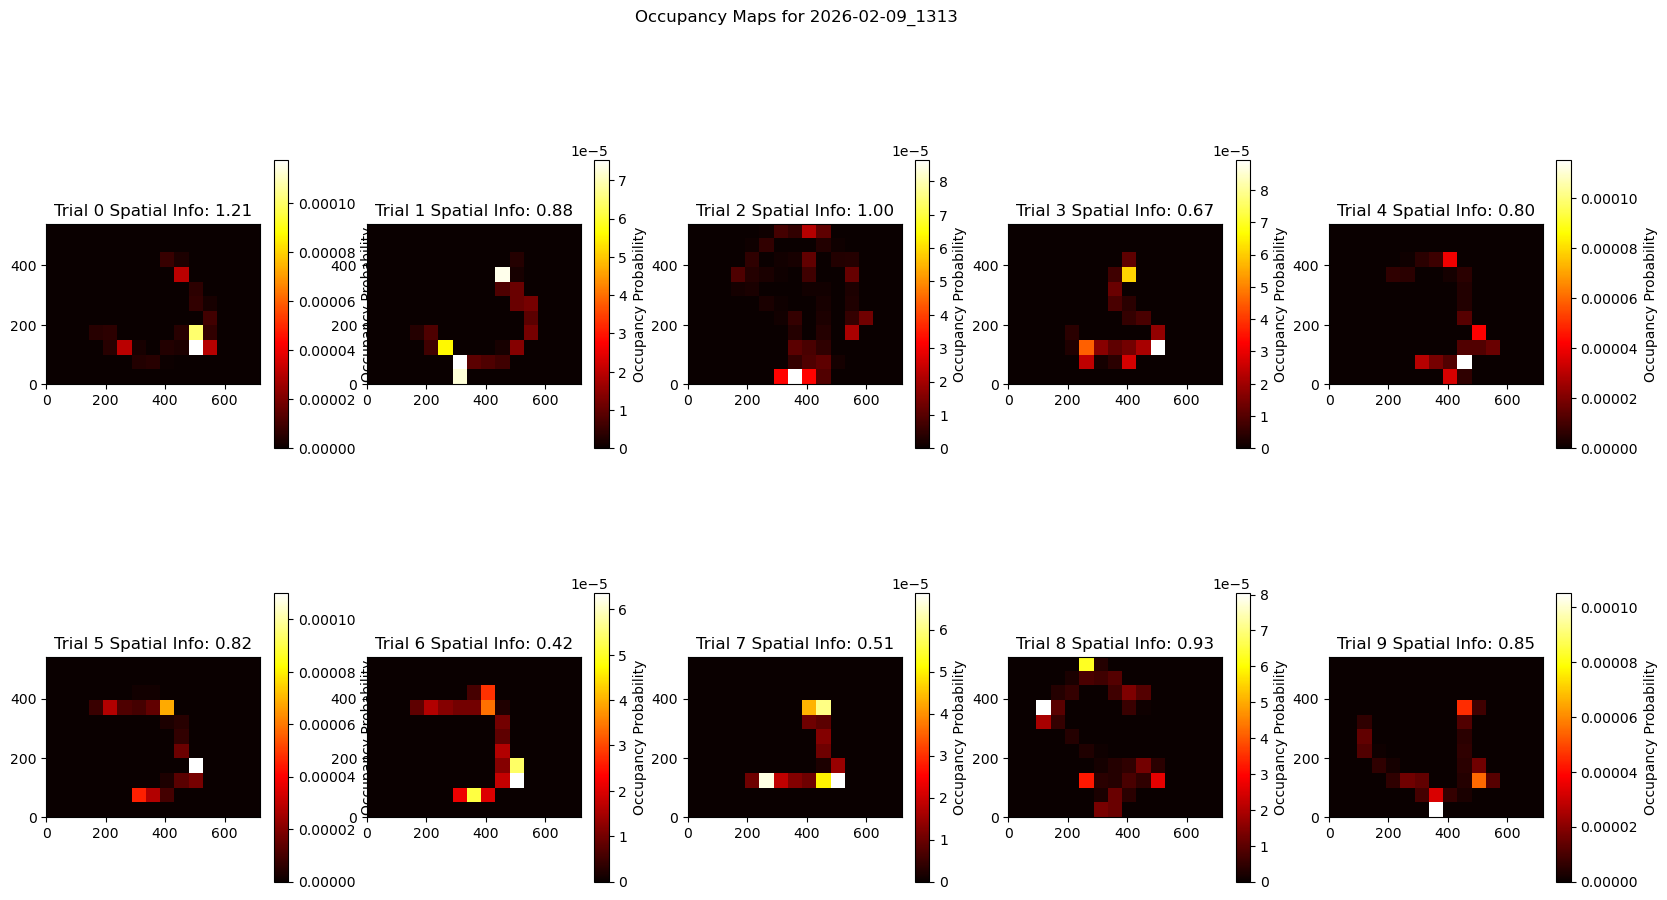

In [2]:
trial_data.plot_all_occupancy_maps()

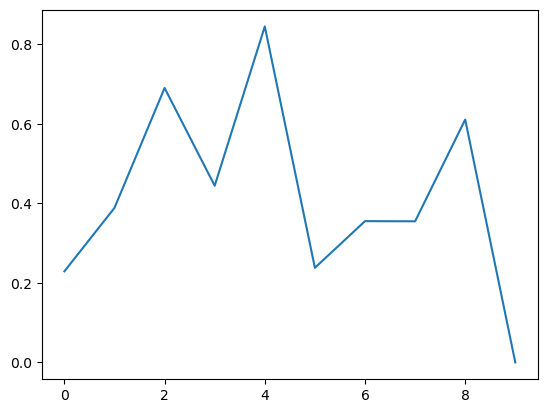

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

angles0 = trial_data.calculate_angle_distribution(9)

# Compare distribution of angles across trials. To do this, calculate angle distributions for each trial, then
# Compare distributions using a 2D similarity metric like KL divergence implemented with scipy.stats.entropy. This will give a measure of how similar the angle distributions are across trials, which can be related to spatial information content.
kls = []
for trial_num in trial_data.trial_data['trial_num'].unique():
    angles = trial_data.calculate_angle_distribution(trial_num)
    kl_divergence = entropy(angles0, angles)

    # Drop the inf and nan values from the KL divergence calculation, then calculate the average KL divergence across all bins to get a single value for each trial. This will allow you to compare the overall similarity of the angle distributions across trials.
    kl_divergence = kl_divergence[np.isfinite(kl_divergence)]
    kl_divergence = np.mean(kl_divergence)
    kls.append(kl_divergence)
    # print(f'Trial {trial_num} KL Divergence from Trial 0: {kl_divergence:.4f}')

plt.plot(trial_data.trial_data['trial_num'].unique(), kls)